# Morton Coverage of Linestrings — Antarctic InSAR Grounding Line

`mortie.linestring_coverage()` rasterizes an open polyline (or list of polylines) into a contiguous chain of HEALPix cells at a given order, returning morton indices.

**Return-shape contract**
- Single linestring → 1-D `np.ndarray` (sorted, unique).
- Multi-linestring → `list` of 1-D arrays, one per line (lengths may differ; not deduplicated across lines).

**Algorithm** (reused from the polygon-coverage Phase A). For each consecutive vertex pair, sample the great-circle arc at half-cell-resolution spacing and rasterize each sample. The result is a connected cell chain at the requested order (default `order=18`).

This notebook:
1. Demonstrates the API on a synthetic linestring.
2. Queries **NSIDC MEaSUREs InSAR Grounding Line v2** (NSIDC-0498) via `earthaccess`, loads the geopackage with `geopandas`, and unpacks the shapely `MultiLineString` into lat/lon arrays for `linestring_coverage`.
3. Plots the morton cells in a south-polar-stereographic projection.
4. Demonstrates two buffer strategies around the line:
   - `morton_buffer(cells, k=N)` — the existing k-cell-ring buffer from PR #17.
   - `morton_buffer_meters(cells, width_m=…)` — a convenience wrapper that picks `k` from a metric width (rounded up to the nearest whole cell width).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.geometry import LineString, MultiLineString

import mortie
print('mortie version:', mortie.__version__)


mortie version: 0.4.0


## Rendering helpers

Reused/adapted from `morton_coverage_example.ipynb`. Converts morton cells to shapely polygons for plotting, and splits linestrings that cross the antimeridian.

In [2]:
def morton_cell_geometries(morton_indices, step=16):
    """Convert morton indices to shapely polygons in lon/lat coords.

    Backed by `mortie.mort2polygon`, which uses the Rust HEALPix crate for
    boundary computation and handles antimeridian-touching cells with the
    same majority-hemisphere normalisation that `mort2bbox` uses.
    """
    if len(morton_indices) == 0:
        return []
    polys = mortie.mort2polygon(np.asarray(morton_indices), step=step)
    if isinstance(polys[0][0], (int, float)):
        polys = [polys]
    return [ShapelyPolygon((lon, lat) for lat, lon in p) for p in polys]


def plot_cells(ax, morton_indices, facecolor='#4a90e2', edgecolor='black',
               alpha=0.45, linewidth=0.2, step=8):
    """Render a set of morton cells on a cartopy axis."""
    if len(morton_indices) == 0:
        return
    geoms = morton_cell_geometries(morton_indices, step=step)
    ax.add_geometries(
        geoms, crs=ccrs.PlateCarree(),
        facecolor=facecolor, edgecolor=edgecolor,
        alpha=alpha, linewidth=linewidth,
    )


def plot_line(ax, lats, lons, color='crimson', lw=1.2):
    """Plot a lat/lon polyline on a cartopy axis (splits at antimeridian)."""
    lons = np.asarray(lons)
    lats = np.asarray(lats)
    dlon = np.abs(np.diff(lons))
    breaks = np.where(dlon > 180)[0]
    start = 0
    for b in list(breaks) + [len(lons) - 1]:
        sl = slice(start, b + 1)
        ax.plot(lons[sl], lats[sl], color=color, lw=lw, transform=ccrs.PlateCarree())
        start = b + 1


## 1. Synthetic example — a single linestring

A short polyline across the North Atlantic. We sweep three HEALPix orders so you can see the cell-size/coverage tradeoff.

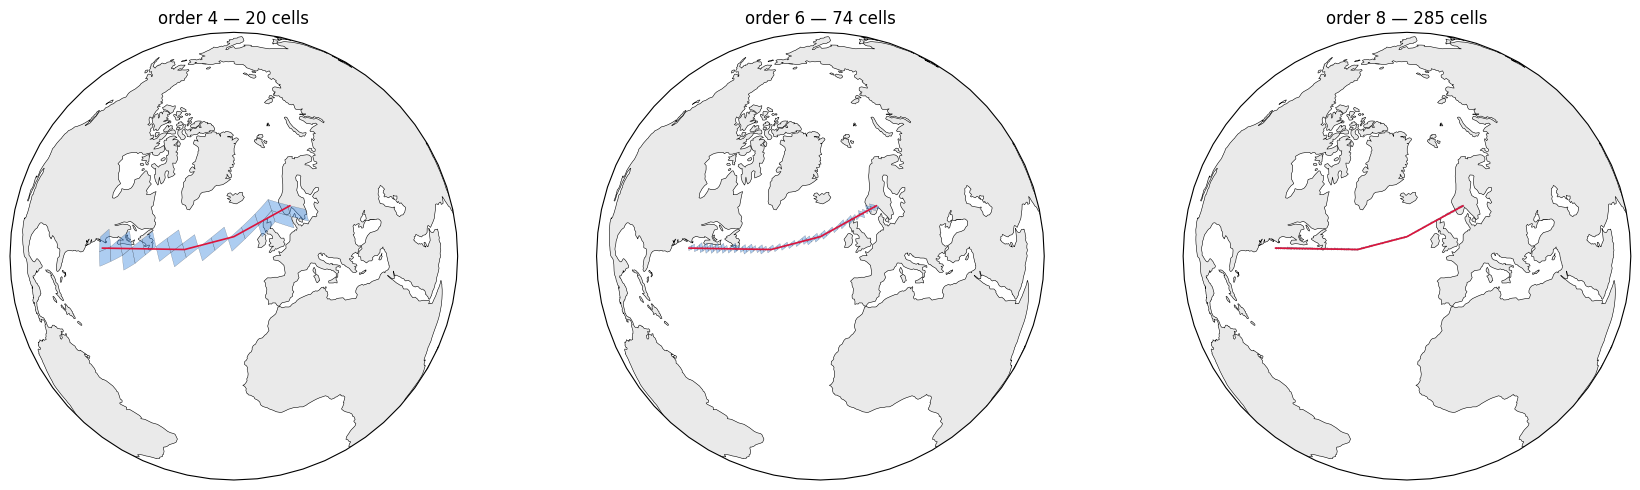

In [3]:
lats = np.array([40.0, 50.0, 55.0, 60.0])
lons = np.array([-70.0, -40.0, -20.0, 10.0])

fig = plt.figure(figsize=(18, 5))
proj = ccrs.Orthographic(central_longitude=-20, central_latitude=50)
for i, order in enumerate([4, 6, 8]):
    ax = fig.add_subplot(1, 3, i + 1, projection=proj)
    ax.set_global()
    ax.coastlines(resolution='110m', lw=0.4)
    ax.add_feature(cfeature.LAND, facecolor='#eaeaea')
    cells = mortie.linestring_coverage(lats, lons, order=order)
    plot_cells(ax, cells, step=4)
    plot_line(ax, lats, lons)
    ax.set_title(f'order {order} — {len(cells)} cells')
plt.tight_layout()
plt.show()

## 2. Real data — NSIDC InSAR Grounding Line (Antarctica)

`NSIDC-0498` (MEaSUREs Antarctic Grounding Line from Differential Satellite Radar Interferometry, **v2**, DOI [10.5067/IKBWW4RYHF1Q](https://doi.org/10.5067/IKBWW4RYHF1Q)) ships both shapefiles and **geopackages** containing polyline features for each acquisition. We:

1. Use `earthaccess` to search CMR and download one granule.
2. Load with `geopandas.read_file` (GeoPackage via pyogrio).
3. Unpack shapely `LineString` / `MultiLineString` geometries into lat/lon arrays.
4. Call `mortie.linestring_coverage(...)` at order 10 (~10 km cells) for the whole file.

> **First run** will prompt for NASA Earthdata credentials via `earthaccess.login(persist=True)` (stored in `~/.netrc`). Subsequent runs reuse the stored credentials.

In [4]:
import earthaccess
from pathlib import Path

auth = earthaccess.login(persist=True)

# MEaSUREs Antarctic Grounding Line from Differential Satellite Radar
# Interferometry, v2 — https://nsidc.org/data/nsidc-0498/versions/2
# DOI: 10.5067/IKBWW4RYHF1Q. Ships as both shapefile and geopackage.
results = earthaccess.search_data(short_name='NSIDC-0498', version='2', count=5)
if not results:
    raise RuntimeError('No granules found — check earthaccess login and CMR')
print(f'{len(results)} granules (short_name=NSIDC-0498, version=2)')

# Download one granule to a local cache
cache = Path('./insar_gl_cache')
cache.mkdir(exist_ok=True)
files = earthaccess.download(results[:1], local_path=str(cache))
print('Downloaded:', files)

2 granules (short_name=NSIDC-0498, version=2)


/home/espg/.conda/envs/mortie/lib/python3.13/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/home/espg/.conda/envs/mortie/lib/python3.13/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Downloaded: [PosixPath('insar_gl_cache/InSAR_GL_Antarctica_v02.1.gpkg')]


In [5]:
import geopandas as gpd

# Pick the .gpkg file(s) from the downloaded set
gpkg_files = [Path(f) for f in files if str(f).lower().endswith('.gpkg')]
if not gpkg_files:
    # Some granules bundle multiple assets — search the cache recursively
    gpkg_files = list(cache.rglob('*.gpkg'))
assert gpkg_files, f'No .gpkg asset found in downloaded granule: {files}'

gdf = gpd.read_file(gpkg_files[0])
print(f'loaded {len(gdf)} features from {gpkg_files[0].name}')
print('CRS:', gdf.crs)
print('geometry types:', gdf.geom_type.value_counts().to_dict())

# Reproject to EPSG:4326 (lon/lat in degrees) if needed
if gdf.crs and gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(4326)
gdf.head()

loaded 1820 features from InSAR_GL_Antarctica_v02.1.gpkg
CRS: EPSG:3031
geometry types: {'MultiLineString': 1820}


,Glac_Name,Sensor,Track,Year,Time_s,Date_1,Orbit_1,Date_2,Orbit_2,Date_3,Orbit_3,Date_4,Orbit_4,Filename,geometry
0,Pine Island,ICEYE,13,2024,27605,2024-07-22,20892,2024-07-23,20907,2024-07-23,20922,2024-07-24,20922.0,gl_ICEYE-X6_9999_9999_ASC_20240722_224224-2024...,"MULTILINESTRING ((-99.3533 -74.99259, -99.3766..."
1,Pine Island,ICEYE,13,2024,27590,2024-07-21,20877,2024-07-22,20892,2024-07-22,20907,2024-07-23,20907.0,gl_ICEYE-X6_9999_9999_ASC_20240721_224215-2024...,"MULTILINESTRING ((-99.36349 -74.9926, -99.3821..."
2,Pine Island,ICEYE,13,2024,27545,2024-07-18,20832,2024-07-19,20847,2024-07-21,20892,2024-07-22,20892.0,gl_ICEYE-X6_9999_9999_ASC_20240718_224150-2024...,"MULTILINESTRING ((-99.35138 -74.99223, -99.369..."
3,Pine Island,ICEYE,13,2024,27530,2024-07-17,20817,2024-07-18,20832,2024-07-18,20847,2024-07-19,20847.0,gl_ICEYE-X6_9999_9999_ASC_20240717_224141-2024...,"MULTILINESTRING ((-99.34534 -74.99074, -99.354..."
4,Pine Island,ICEYE,13,2024,27515,2024-07-16,20802,2024-07-17,20817,2024-07-17,20832,2024-07-18,20832.0,gl_ICEYE-X6_9999_9999_ASC_20240716_224132-2024...,"MULTILINESTRING ((-99.37772 -75.05753, -99.354..."


### Unpacking shapely geometries → lat/lon arrays

`linestring_coverage` accepts plain lat/lon arrays (to avoid adding a shapely dependency to `mortie`). The helper below converts each shapely `LineString` / `MultiLineString` into the `(lats, lons)` pair (or list-of-pairs) the function expects.

In [6]:
gdf

,Glac_Name,Sensor,Track,Year,Time_s,Date_1,Orbit_1,Date_2,Orbit_2,Date_3,Orbit_3,Date_4,Orbit_4,Filename,geometry
0,Pine Island,ICEYE,13,2024,27605,2024-07-22,20892,2024-07-23,20907,2024-07-23,20922,2024-07-24,20922.0,gl_ICEYE-X6_9999_9999_ASC_20240722_224224-2024...,"MULTILINESTRING ((-99.3533 -74.99259, -99.3766..."
1,Pine Island,ICEYE,13,2024,27590,2024-07-21,20877,2024-07-22,20892,2024-07-22,20907,2024-07-23,20907.0,gl_ICEYE-X6_9999_9999_ASC_20240721_224215-2024...,"MULTILINESTRING ((-99.36349 -74.9926, -99.3821..."
2,Pine Island,ICEYE,13,2024,27545,2024-07-18,20832,2024-07-19,20847,2024-07-21,20892,2024-07-22,20892.0,gl_ICEYE-X6_9999_9999_ASC_20240718_224150-2024...,"MULTILINESTRING ((-99.35138 -74.99223, -99.369..."
3,Pine Island,ICEYE,13,2024,27530,2024-07-17,20817,2024-07-18,20832,2024-07-18,20847,2024-07-19,20847.0,gl_ICEYE-X6_9999_9999_ASC_20240717_224141-2024...,"MULTILINESTRING ((-99.34534 -74.99074, -99.354..."
4,Pine Island,ICEYE,13,2024,27515,2024-07-16,20802,2024-07-17,20817,2024-07-17,20832,2024-07-18,20832.0,gl_ICEYE-X6_9999_9999_ASC_20240716_224132-2024...,"MULTILINESTRING ((-99.37772 -75.05753, -99.354..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1815,Moscow,ERS,345,1996,1527,1996-03-14,24381,1996-03-15,4708,1996-04-18,24882,1996-04-19,5209.0,coco24381-04708-24882-05209.flat.PRC.smooth.geo,"MULTILINESTRING ((121.04437 -67.12816, 121.100..."
1816,Stancomb,ERS,218,1996,13044,1995-10-17,22250,1995-10-18,2577,1996-03-05,24254,1996-03-06,4581.0,coco22250-02577-24254-04581.flat.PRC.smooth.geo,"MULTILINESTRING ((-26.64294 -76.12448, -26.614..."
1817,Ross,ERS,454,1996,54944,1996-02-15,23989,1996-02-16,4316,1996-03-21,24490,1996-03-22,4817.0,coco23989-04316-24490-04817.flat.PRC.smooth.geo,"MULTILINESTRING ((-150.21655 -79.1451, -150.13..."
1818,Abbot,ERS,425,1996,52517,1995-10-31,22457,1995-11-01,2784,1996-03-19,24461,1996-03-20,4788.0,coco22457-02784-24461-04788.flat.PRC.smooth.geo,"MULTILINESTRING ((-100.61383 -72.55687, -100.6..."


In [7]:
def shapely_to_latlon(geom):
    """Unpack a shapely LineString or MultiLineString into arrays.

    Returns
    -------
    (lats, lons) for a LineString (pair of 1-D arrays),
    (list_of_lats, list_of_lons) for a MultiLineString.
    """
    if isinstance(geom, LineString):
        xs, ys = np.asarray(geom.xy[0]), np.asarray(geom.xy[1])
        return ys, xs  # shapely xy = (lon, lat) → return (lats, lons)
    if isinstance(geom, MultiLineString):
        lats_parts, lons_parts = [], []
        for ls in geom.geoms:
            xs, ys = np.asarray(ls.xy[0]), np.asarray(ls.xy[1])
            lats_parts.append(ys); lons_parts.append(xs)
        return lats_parts, lons_parts
    raise TypeError(f'expected LineString or MultiLineString, got {type(geom).__name__}')


# Collect all vertices across every feature into ONE multi-linestring input —
# i.e., a list of (lats, lons) pairs where each pair is one polyline.
lats_parts, lons_parts = [], []
for geom in gdf.geometry:
    if geom is None or geom.is_empty:
        continue
    la, lo = shapely_to_latlon(geom)
    if isinstance(la, list):
        lats_parts.extend(la); lons_parts.extend(lo)
    else:
        lats_parts.append(la); lons_parts.append(lo)

print(f'{len(lats_parts)} linestrings, {sum(len(p) for p in lats_parts):,} total vertices')

19553 linestrings, 1,609,430 total vertices


In [8]:
# Coverage at order 10 (~10 km) — per-line list of arrays
import time
t0 = time.perf_counter()
per_line = mortie.linestring_coverage(lats_parts, lons_parts, order=10)
dt = (time.perf_counter() - t0) * 1000
print(f'{len(per_line)} per-line arrays in {dt:.1f} ms')
print(f'cell counts: min={min(len(a) for a in per_line)}, '
      f'median={int(np.median([len(a) for a in per_line]))}, '
      f'max={max(len(a) for a in per_line)}')

# Union across all lines for plotting
all_cells = np.unique(np.concatenate(per_line))
print(f'union across all lines: {len(all_cells):,} cells')

19553 per-line arrays in 242.0 ms
cell counts: min=1, median=2, max=92
union across all lines: 10,502 cells


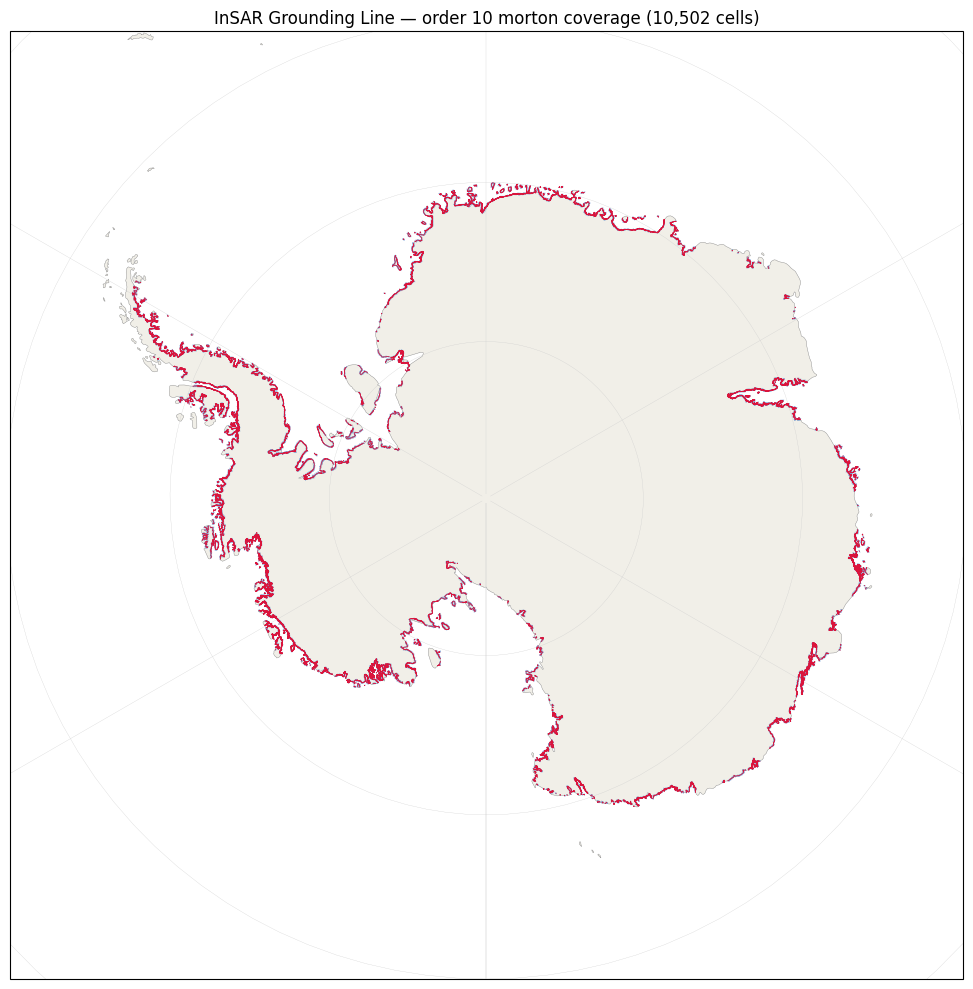

In [9]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='#f1efe8')
ax.coastlines(resolution='50m', lw=0.3, color='#888')
ax.gridlines(draw_labels=False, lw=0.2, color='#ccc')

# Coverage cells in blue
plot_cells(ax, all_cells, facecolor='#4a90e2', edgecolor='#2858a0',
           alpha=0.6, linewidth=0.1, step=4)

# Overlay the raw linestrings in red
for la, lo in zip(lats_parts, lons_parts):
    plot_line(ax, la, lo, color='crimson', lw=0.5)

ax.set_title(f'InSAR Grounding Line — order 10 morton coverage ({len(all_cells):,} cells)')
plt.tight_layout()
plt.show()

## 3. Buffering the coverage

Two APIs:

| function | input | semantics |
|---|---|---|
| `morton_buffer(cells, k=N)` | integer `k` (cells) | returns the N-cell ring around the input (exclusive) |
| `morton_buffer_meters(cells, width_m=W)` | metric width in meters | picks `k = ceil(W / cell_width)` at the input order, then calls `morton_buffer`. **Approximate** — result is rounded UP to the nearest whole cell width, so the buffer covers *at least* `W` meters. |

Both return only the **border ring**, not the input cells. Use `np.union1d(cells, border)` to get the filled buffer.

In [10]:
# Use one line of the InSAR GL dataset (the longest one) as the demo subject
lengths = [len(a) for a in per_line]
idx = int(np.argmax(lengths))
line_cells = per_line[idx]
la, lo = lats_parts[idx], lons_parts[idx]
print(f'line #{idx}: {len(la)} vertices -> {len(line_cells)} cells at order 10')

# (a) k-based buffer: 1-cell and 3-cell rings
ring_k1 = mortie.morton_buffer(line_cells, k=1)
ring_k3 = mortie.morton_buffer(line_cells, k=3)

# (b) meter-based buffer: ~50 km
# at order 10, cell width is ~11.2 km; ceil(50/11.2) = 5
ring_50km = mortie.morton_buffer_meters(line_cells, width_m=50_000.0)

print(f'ring k=1: {len(ring_k1)} cells')
print(f'ring k=3: {len(ring_k3)} cells')
print(f'ring 50 km (meter-based): {len(ring_50km)} cells')

line #18509: 469 vertices -> 92 cells at order 10
ring k=1: 149 cells
ring k=3: 415 cells
ring 50 km (meter-based): 1169 cells


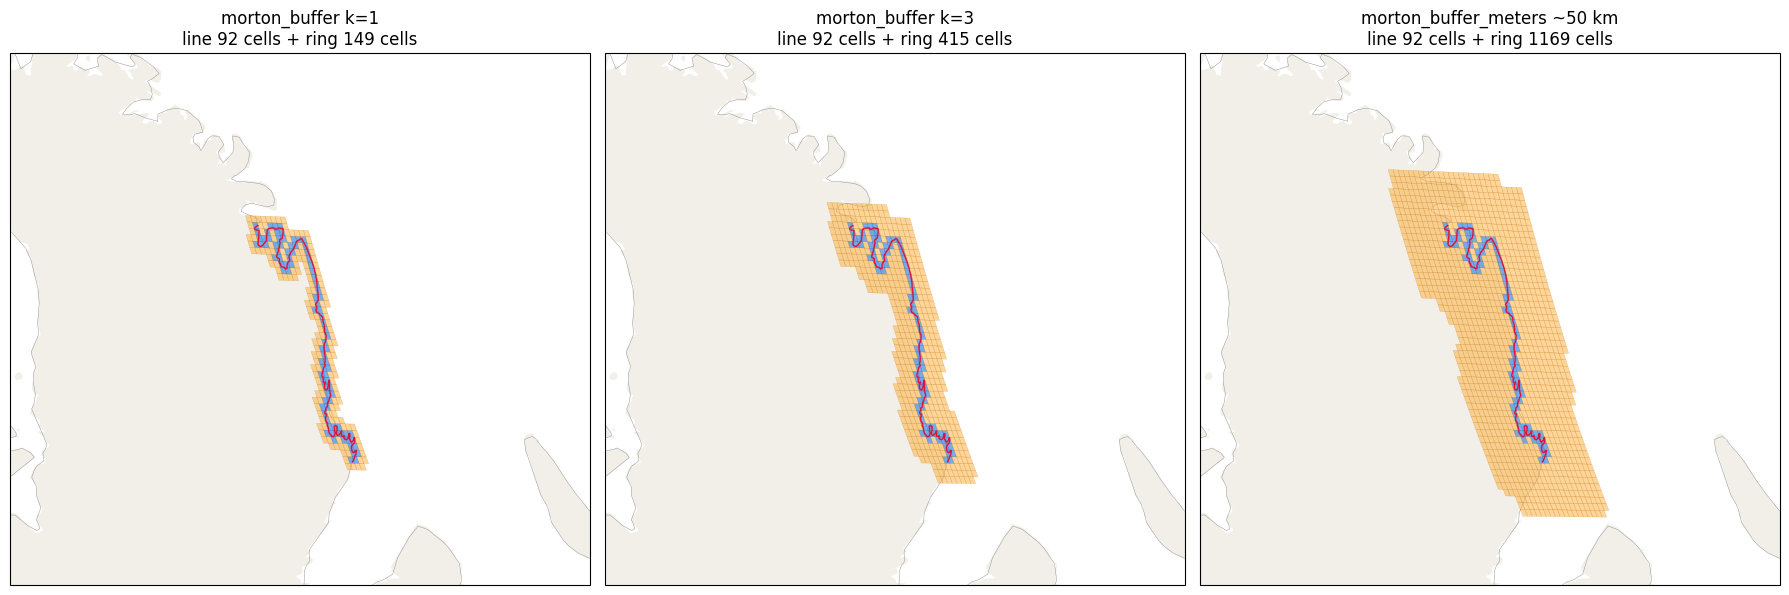

In [11]:
# Visualise the three buffers side-by-side around the same line
fig = plt.figure(figsize=(18, 7))

for i, (name, ring) in enumerate([
    ('morton_buffer k=1', ring_k1),
    ('morton_buffer k=3', ring_k3),
    ('morton_buffer_meters ~50 km', ring_50km),
]):
    ax = fig.add_subplot(1, 3, i + 1, projection=ccrs.SouthPolarStereo())
    # Zoom to the line's bounding box with a little padding
    lat_min, lat_max = np.min(la) - 1.5, np.max(la) + 1.5
    lon_min, lon_max = np.min(lo) - 4, np.max(lo) + 4
    ax.set_extent([lon_min, lon_max, max(lat_min, -90), min(lat_max, -60)],
                  ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#f1efe8')
    ax.coastlines(resolution='50m', lw=0.3, color='#888')

    plot_cells(ax, line_cells, facecolor='#4a90e2', edgecolor='#2858a0',
               alpha=0.75, step=4)
    plot_cells(ax, ring, facecolor='#ffb347', edgecolor='#c07000',
               alpha=0.55, step=4)
    plot_line(ax, la, lo, color='crimson', lw=1.0)
    ax.set_title(f'{name}\nline {len(line_cells)} cells + ring {len(ring)} cells')

plt.tight_layout()
plt.show()

### Filled buffer (union pattern)

`morton_buffer` returns **only the ring**. Union with the original cells to get a filled buffer.

filled 50km buffer: 1261 cells (= 92 line + 1169 ring)


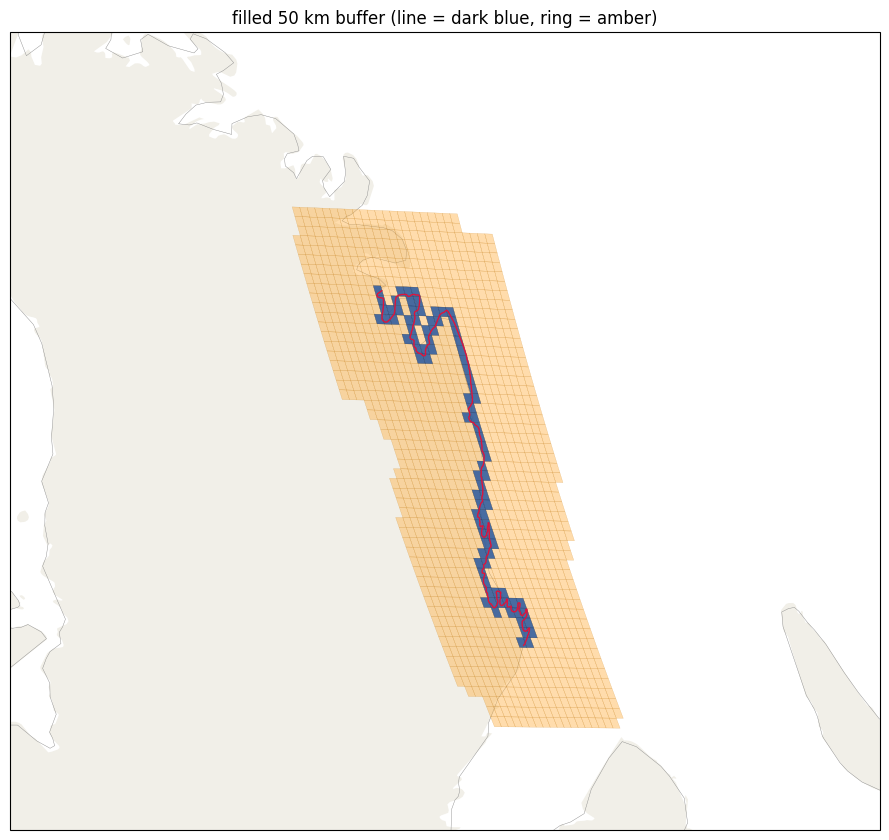

In [12]:
filled_50km = np.union1d(line_cells, ring_50km)
print(f'filled 50km buffer: {len(filled_50km)} cells '
      f'(= {len(line_cells)} line + {len(ring_50km)} ring)')

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
lat_min, lat_max = np.min(la) - 1.5, np.max(la) + 1.5
lon_min, lon_max = np.min(lo) - 4, np.max(lo) + 4
ax.set_extent([lon_min, lon_max, max(lat_min, -90), min(lat_max, -60)],
              ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='#f1efe8')
ax.coastlines(resolution='50m', lw=0.3, color='#888')

plot_cells(ax, filled_50km, facecolor='#ffb347', edgecolor='#c07000',
           alpha=0.45, step=4)
plot_cells(ax, line_cells, facecolor='#2858a0', edgecolor='#1a3a6e',
           alpha=0.85, step=4)
plot_line(ax, la, lo, color='crimson', lw=1.0)
ax.set_title('filled 50 km buffer (line = dark blue, ring = amber)')
plt.tight_layout()
plt.show()